In [34]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import nltk as nk


In [ ]:
df=pd.read_csv('spam.csv',encoding='latin-1')
df.sample

<bound method NDFrame.sample of         v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN

## 1 Dataset Cleaning

In [13]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
df.rename(columns={'v1':'target','v2':'email_text'},inplace=True)

## labeling the target: Spam=1,ham=0

In [20]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

df['target']=encoder.fit_transform(df['target'])

df.sample(10)

,target,email_text
1200,0,Otherwise had part time job na-tuition..
1222,0,Teach me apps da. When you come to college.
4050,0,"Motivate Behind every darkness, there is a shi..."
2896,0,ÌÏ collecting ur laptop then going to configur...
786,0,It does it on its own. Most of the time it fix...
4119,0,Babe! How goes that day ? What are you up to ?...
3113,0,Yes watching footie but worried we're going to...
2952,1,"URGENT! Your mobile was awarded a å£1,500 Bonu..."
2656,0,Feel like trying kadeem again? :V
4818,0,Got smaller capacity one? Quite ex...


In [22]:
##check for missing and duplicate values 
df.isnull().sum()

target        0
email_text    0
dtype: int64

In [ ]:
##check for duplicated rows
df.duplicated().sum()

df=df.drop_duplicates(keep='first')


## 2 Exploratory Data Analysis(EDA)

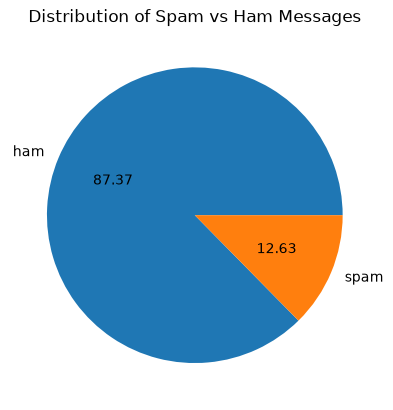

In [32]:
## check for total ham and spam vaues and plot a graph
counts=df['target'].value_counts()
plt.pie(counts,labels=['ham','spam'],autopct='%0.2f')
plt.title('Distribution of Spam vs Ham Messages')
plt.show()

# data is imbalanced

In [43]:
nk.download('punkt')
nk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\SK\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [47]:
##new column containing charachter lenght of corressponding email text
df['email_text_char_lenght']=df['email_text'].apply(len)

df.head()

,target,email_text,email_text_lenght,email_text_words_len,email_text_char_lenght
0,0,"Go until jurong point, crazy.. Available only ...",111,24,111
1,0,Ok lar... Joking wif u oni...,29,8,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,155
3,0,U dun say so early hor... U c already then say...,49,13,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,61


In [ ]:
## tokanize each email into words and save the count in new column
df['email_text_words_len']=df['email_text'].apply(lambda x:len(nk.word_tokenize(x)))

In [53]:
df.head()

,target,email_text,email_text_char_lenght,email_text_words_len
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [ ]:
## Snetence tokanization
df['email_text_sentence_len']=df['email_text'].apply(lambda x:len(nk.sent_tokenize(x)))

df.head(50)